In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [17]:
base_path = Path(os.getenv("BASIC_JSON_RESPONSES"))

files = {
    "GPT": base_path / "basic/nutria_gpt.json",
    "Gemini": base_path / "basic/nutria_gemini.json",
    "Anthropic": base_path / "basic/nutria_anthropic.json"
}

In [18]:
processing_data = []

for model_name, file_path in files.items():
    with open(file_path, 'r') as f:
        data = json.load(f)
    for entry in data:
        processing_data.append({
            "model": model_name,
            "processing_time": entry.get("processing_time", None)
        })

# Create DataFrame
df = pd.DataFrame(processing_data)

In [19]:
summary = df.groupby("model")["processing_time"].agg(["count", "mean", "std", "min", "max"]).reset_index()
print("🔍 Processing Time Summary per Model:")
display(summary)

🔍 Processing Time Summary per Model:


,model,count,mean,std,min,max
0,Anthropic,48,8.712373,2.720498,3.320110,14.089252
1,GPT,50,2.946942,1.161442,1.741543,6.681981
2,Gemini,50,3.168703,0.862631,2.019685,6.087730


<Figure size 1000x600 with 0 Axes>

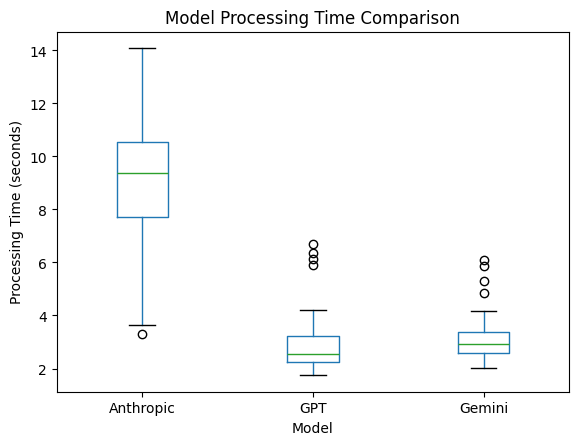

In [20]:
plt.figure(figsize=(10, 6))
df.boxplot(column="processing_time", by="model", grid=False)
plt.title("Model Processing Time Comparison")
plt.suptitle("")  # Remove automatic matplotlib title
plt.ylabel("Processing Time (seconds)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.show()

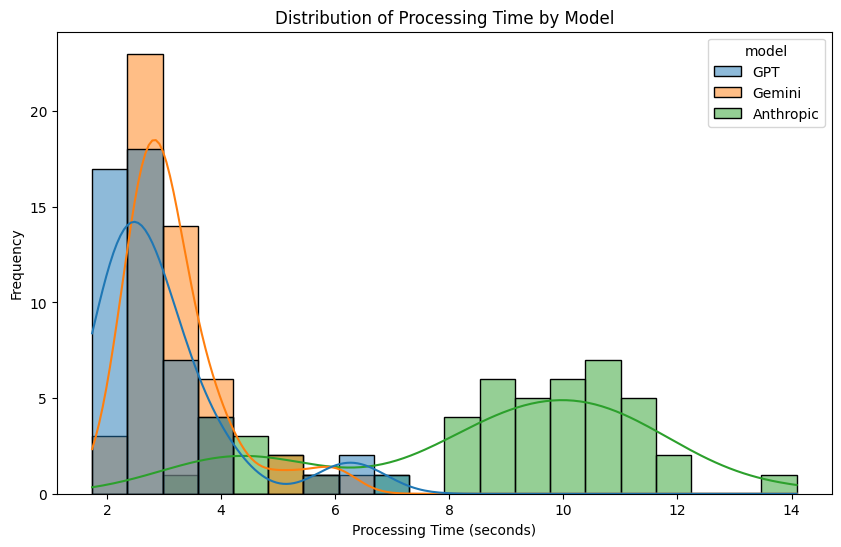

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="processing_time", hue="model", kde=True, bins=20)
plt.title("Distribution of Processing Time by Model")
plt.xlabel("Processing Time (seconds)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
df.head(5)

,id,expert_serving_size,observations,gemini_serving_size,gpt_serving_size,anthropic_serving_size
0,1,353,NaN,330,300,500
1,2,268,NaN,250,300,280
2,3,340,NaN,250,180,280
3,4,223,NaN,350,280,280
4,5,340,NaN,400,250,280


In [ ]:
df.describe()

,id,expert_serving_size,gemini_serving_size,gpt_serving_size,anthropic_serving_size
count,48.000000,48.00000,48.000000,48.000000,48.000000
mean,24.895833,244.62500,259.187500,243.125000,244.062500
std,14.566414,286.10522,131.562728,115.834736,120.533637
min,1.000000,0.00000,28.000000,20.000000,0.000000
25%,12.750000,97.50000,150.000000,150.000000,150.000000
50%,24.500000,165.00000,250.000000,250.000000,272.500000
75%,36.250000,325.00000,350.000000,350.000000,281.250000
max,50.000000,1670.00000,500.000000,500.000000,500.000000


In [ ]:
df = df[df['expert_serving_size']!=0]
df = df[df['id']!=31]
df = df[df['id']!=28]
df.shape

(39, 6)

In [ ]:
df.describe()

,id,expert_serving_size,gemini_serving_size,gpt_serving_size,anthropic_serving_size
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,22.102564,234.871795,248.487179,236.153846,234.102564
std,13.825596,157.910564,134.014310,119.552133,120.464407
min,1.000000,30.000000,28.000000,20.000000,0.000000
25%,10.500000,100.000000,150.000000,150.000000,150.000000
50%,21.000000,205.000000,250.000000,250.000000,250.000000
75%,32.500000,330.000000,350.000000,310.000000,280.000000
max,48.000000,700.000000,500.000000,500.000000,500.000000


In [ ]:
metrics = ['serving_size']
all_results = []

# true results vs predictions for each model
true_suffix = 'expert_'
pred_suffixes = ['gemini_', 'gpt_', 'anthropic_']

In [ ]:
def plot_metric_comparison(data, metrics, true_suffix=true_suffix, pred_suffixes=pred_suffixes):
    all_results = []

    for pred_suffix in pred_suffixes:
        model_results = []
        for metric in metrics:
            y_true = data[f"{true_suffix}{metric}"]
            y_pred = data[f"{pred_suffix}{metric}"]

            mae = mean_absolute_error(y_true, y_pred)

            # Avoid division by near-zero values in MAPE
            mask = y_true > 1e-3
            mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100 if mask.sum() > 0 else np.nan

            rmse = root_mean_squared_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)

            within_20pct = np.mean(np.abs(y_true - y_pred) / y_true <= 0.20) * 100

            t_stat, p_value = ttest_rel(y_true, y_pred)

            model_results.append({
                "Model": pred_suffix.strip('_').upper(),
                "Metric": metric.capitalize(),
                "MAE": round(mae, 2),
                "MAPE (%)": round(mape, 2) if not np.isnan(mape) else "N/A",
                "RMSE": round(rmse, 2),
                "R2 Score": round(r2, 3),
                "Within ±20%": round(within_20pct, 2),
                "T-test p-value": round(p_value, 4)
            })

        all_results.extend(model_results)

    return all_results


In [ ]:
results = pd.DataFrame(plot_metric_comparison(df, metrics, true_suffix, pred_suffixes))
print("\n=== COMPARATIVE METRICS TABLE ===")
results


=== COMPARATIVE METRICS TABLE ===


,Model,Metric,MAE,MAPE (%),RMSE,R2 Score,Within ±20%,T-test p-value
0,GEMINI,Serving_size,82.69,45.25,108.81,0.513,35.90,0.4417
1,GPT,Serving_size,70.10,36.57,98.02,0.605,43.59,0.9362
2,ANTHROPIC,Serving_size,99.18,55.79,139.81,0.195,33.33,0.9731


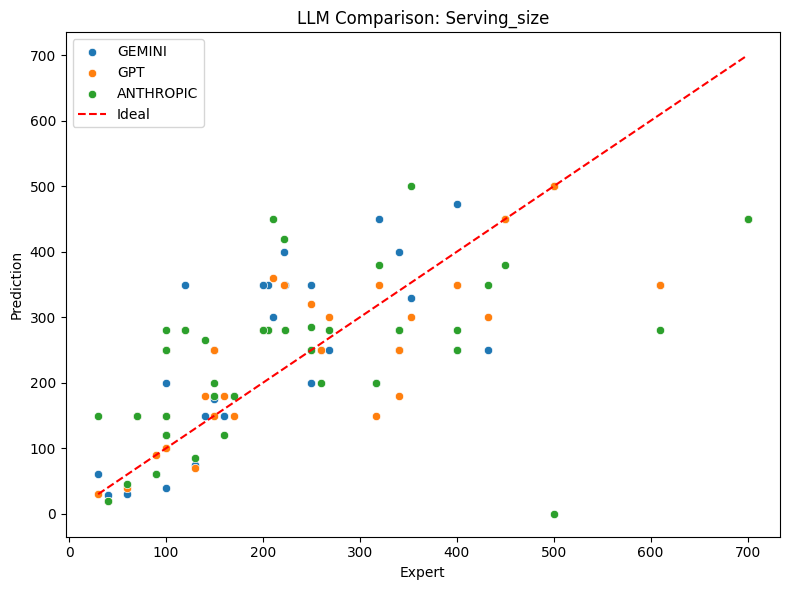

In [ ]:
def plot_metric_distribution(data, metrics, true_suffix, suffixes):
    for metric in metrics:
        plt.figure(figsize=(8, 6))
        for suffix in suffixes:
            model_name = suffix.replace('_', '').upper()
            sns.scatterplot(
                x=f"{true_suffix}{metric}",
                y=f"{suffix}{metric}",
                data=data,
                label=model_name
            )
        min_val = data[f"{true_suffix}{metric}"].min()
        max_val = data[f"{true_suffix}{metric}"].max()
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal")
        plt.xlabel("Expert")
        plt.ylabel("Prediction")
        plt.title(f"LLM Comparison: {metric.capitalize()}")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_metric_distribution(df, metrics, true_suffix, suffixes=pred_suffixes)

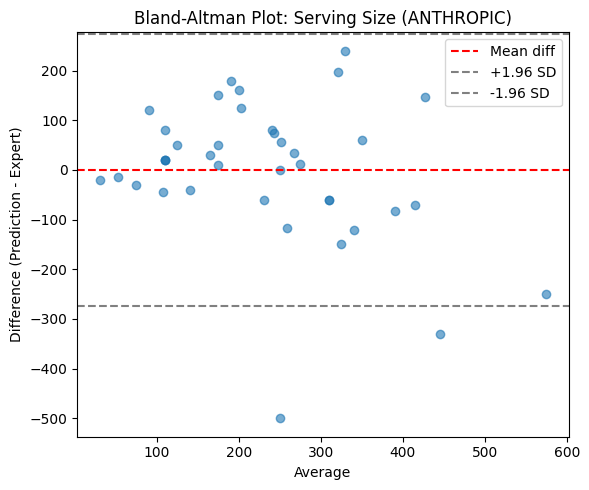

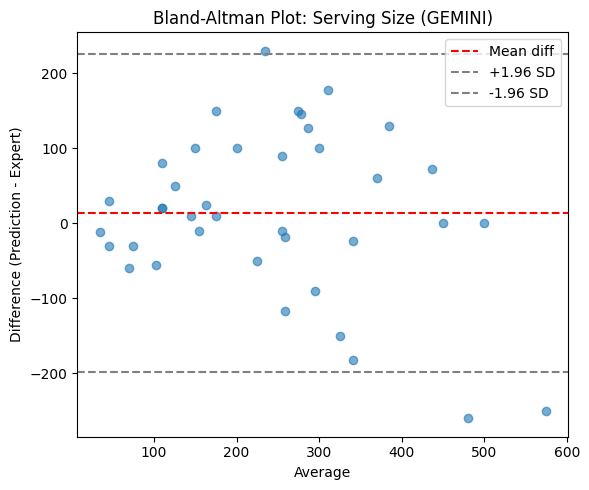

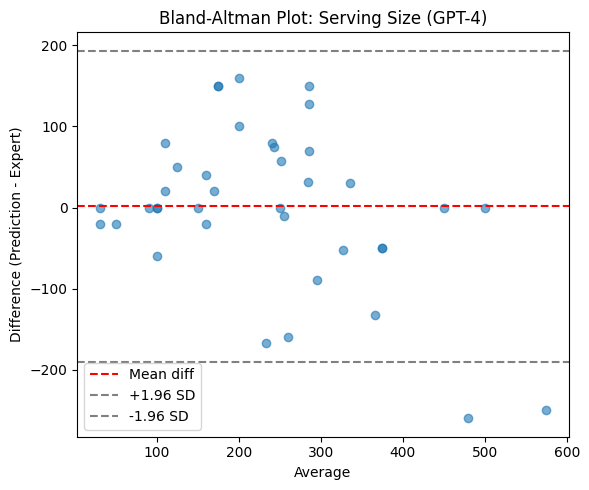

In [ ]:
def bland_altman_plot(y_true, y_pred, metric_name, model_name):
    avg = (y_true + y_pred) / 2
    diff = y_pred - y_true
    mean_diff = np.mean(diff)
    std_diff = np.std(diff)

    plt.figure(figsize=(6, 5))
    plt.scatter(avg, diff, alpha=0.6)
    plt.axhline(mean_diff, color='red', linestyle='--', label='Mean diff')
    plt.axhline(mean_diff + 1.96*std_diff, color='gray', linestyle='--', label='+1.96 SD')
    plt.axhline(mean_diff - 1.96*std_diff, color='gray', linestyle='--', label='-1.96 SD')
    plt.title(f"Bland-Altman Plot: {metric_name} ({model_name})")
    plt.xlabel("Average")
    plt.ylabel("Difference (Prediction - Expert)")
    plt.legend()
    plt.tight_layout()
    plt.show()


bland_altman_plot(df['expert_serving_size'], df['anthropic_serving_size'], "Serving Size", "ANTHROPIC")
bland_altman_plot(df['expert_serving_size'], df['gemini_serving_size'], "Serving Size", "GEMINI")
bland_altman_plot(df['expert_serving_size'], df['gpt_serving_size'], "Serving Size", "GPT-4")